<a href="https://colab.research.google.com/github/adeshsingh5505/BoilerEfficiency/blob/main/datsetAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
from scipy import stats
import os

def calculate_csv_stats(input_path, output_path="stats_output.csv"):
    # Read the CSV file
    df = pd.read_csv(input_path)

    # Define the specific columns to analyze
    selected_columns = ['Flue gas temperature at the upper economizer outlet (left)', 'Flue gas temperature at the upper economizer outlet (right)', 'Upper economiser inlet flue gas oxygen (left)', 'Upper economiser inlet flue gas oxygen (right)', 'Main steam flow rate after compensation', 'Boiler outlet steam temperature']

    # Verify that selected columns exist in the DataFrame
    valid_columns = [col for col in selected_columns if col in df.columns]

    # Initialize lists to store statistics
    stats_dict = {
        'Column': [],
        'Mean': [],
        'Std_Dev': [],
        'Variance': [],
        'Skewness': [],
        'Kurtosis': []
    }

    # Calculate statistics for each specified column
    for column in valid_columns:
        if df[column].dtype in ['float64', 'int64']:
            stats_dict['Column'].append(column)
            # Round all calculations to 2 decimal places
            stats_dict['Mean'].append(round(df[column].mean(), 2))
            stats_dict['Std_Dev'].append(round(df[column].std(), 2))
            stats_dict['Variance'].append(round(df[column].var(), 2))
            stats_dict['Skewness'].append(round(stats.skew(df[column], nan_policy='omit'), 2))
            stats_dict['Kurtosis'].append(round(stats.kurtosis(df[column], nan_policy='omit'), 2))

            # Print statistics for the column
            print(f"\nStatistics for column '{column}':")
            print(f"Mean: {stats_dict['Mean'][-1]:.2f}")
            print(f"Standard Deviation: {stats_dict['Std_Dev'][-1]:.2f}")
            print(f"Variance: {stats_dict['Variance'][-1]:.2f}")
            print(f"Skewness: {stats_dict['Skewness'][-1]:.2f}")
            print(f"Kurtosis: {stats_dict['Kurtosis'][-1]:.2f}")

    # Create DataFrame from statistics
    stats_df = pd.DataFrame(stats_dict)

    # Save to CSV
    stats_df.to_csv(output_path, index=False)
    print(f"\nStatistics saved to {output_path}")

# Example usage
if __name__ == "__main__":
    # Replace 'input.csv' with your CSV file path
    calculate_csv_stats('/content/data modified.csv')


Statistics for column 'Flue gas temperature at the upper economizer outlet (left)':
Mean: 356.88
Standard Deviation: 5.99
Variance: 35.87
Skewness: -0.04
Kurtosis: -0.55

Statistics for column 'Flue gas temperature at the upper economizer outlet (right)':
Mean: 390.97
Standard Deviation: 9.15
Variance: 83.68
Skewness: -0.08
Kurtosis: -0.32

Statistics for column 'Upper economiser inlet flue gas oxygen (left)':
Mean: 2.09
Standard Deviation: 0.34
Variance: 0.11
Skewness: 0.57
Kurtosis: 2.45

Statistics for column 'Upper economiser inlet flue gas oxygen (right)':
Mean: 2.23
Standard Deviation: 0.39
Variance: 0.15
Skewness: 0.69
Kurtosis: 2.44

Statistics for column 'Main steam flow rate after compensation':
Mean: 59.76
Standard Deviation: 2.38
Variance: 5.66
Skewness: -0.29
Kurtosis: 0.72

Statistics for column 'Boiler outlet steam temperature':
Mean: 537.52
Standard Deviation: 4.33
Variance: 18.74
Skewness: -0.25
Kurtosis: -0.04

Statistics saved to stats_output.csv


In [11]:
!pip install tabulate

In [14]:
import pandas as pd
from tabulate import tabulate

# Load the CSV file
df = pd.read_csv("/content/stats_output.csv")

# Print as a visual table
print(tabulate(df, headers='keys', tablefmt='fancy_grid', showindex=False))


╒═════════════════════════════════════════════════════════════╤════════╤═══════════╤════════════╤════════════╤════════════╕
│ Column                                                      │   Mean │   Std_Dev │   Variance │   Skewness │   Kurtosis │
╞═════════════════════════════════════════════════════════════╪════════╪═══════════╪════════════╪════════════╪════════════╡
│ Flue gas temperature at the upper economizer outlet (left)  │ 356.88 │      5.99 │      35.87 │      -0.04 │      -0.55 │
├─────────────────────────────────────────────────────────────┼────────┼───────────┼────────────┼────────────┼────────────┤
│ Flue gas temperature at the upper economizer outlet (right) │ 390.97 │      9.15 │      83.68 │      -0.08 │      -0.32 │
├─────────────────────────────────────────────────────────────┼────────┼───────────┼────────────┼────────────┼────────────┤
│ Upper economiser inlet flue gas oxygen (left)               │   2.09 │      0.34 │       0.11 │       0.57 │       2.45 │
├───────


Statistics for column 'Flue gas temperature at the upper economizer outlet (left)':
Mean: 356.88
Standard Deviation: 5.99
Variance: 35.87
Skewness: -0.04
Kurtosis: -0.55

Statistics for column 'Flue gas temperature at the upper economizer outlet (right)':
Mean: 390.97
Standard Deviation: 9.15
Variance: 83.68
Skewness: -0.08
Kurtosis: -0.32

Statistics for column 'Upper economiser inlet flue gas oxygen (left)':
Mean: 2.09
Standard Deviation: 0.34
Variance: 0.11
Skewness: 0.57
Kurtosis: 2.45

Statistics for column 'Upper economiser inlet flue gas oxygen (right)':
Mean: 2.23
Standard Deviation: 0.39
Variance: 0.15
Skewness: 0.69
Kurtosis: 2.44

Statistics for column 'Main steam flow rate after compensation':
Mean: 59.76
Standard Deviation: 2.38
Variance: 5.66
Skewness: -0.29
Kurtosis: 0.72

Statistics for column 'Boiler outlet steam temperature':
Mean: 537.52
Standard Deviation: 4.33
Variance: 18.74
Skewness: -0.25
Kurtosis: -0.04

Statistics saved to stats_output.csv

Generating bar cha

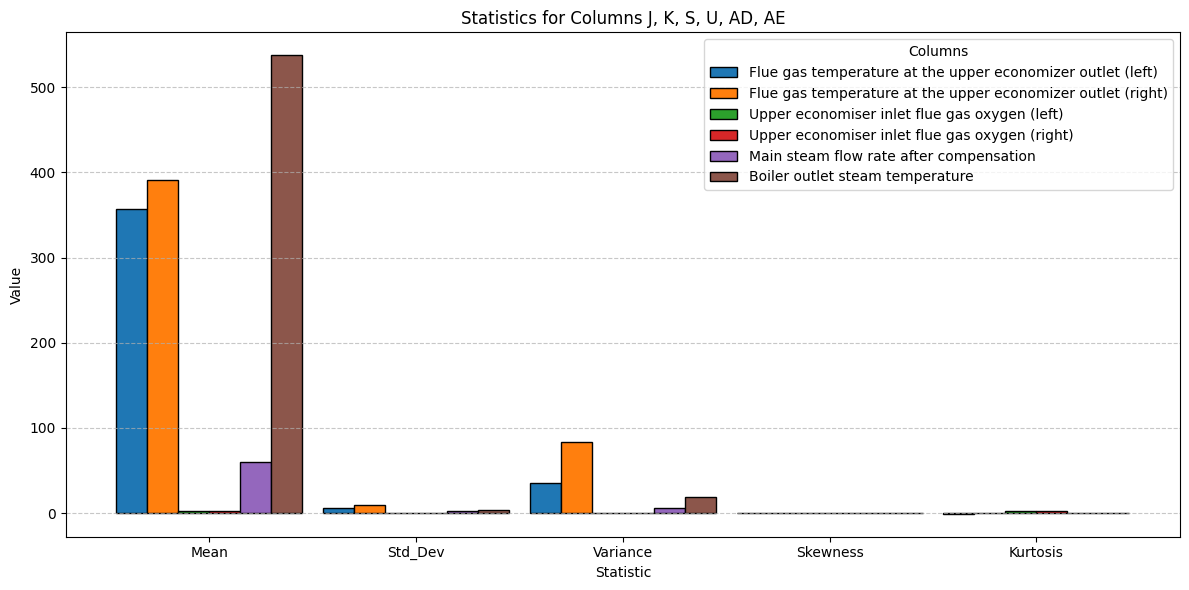

In [18]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import os

def calculate_excel_stats_and_plot(input_path, output_path="stats_output.csv"):
    # Read the Excel file
    df = pd.read_csv(input_path)

    # Define the specific columns to analyze
    selected_columns = ['Flue gas temperature at the upper economizer outlet (left)', 'Flue gas temperature at the upper economizer outlet (right)', 'Upper economiser inlet flue gas oxygen (left)', 'Upper economiser inlet flue gas oxygen (right)', 'Main steam flow rate after compensation', 'Boiler outlet steam temperature']
    # Verify that selected columns exist in the DataFrame
    valid_columns = [col for col in selected_columns if col in df.columns]
    if not valid_columns:
        print("Error: None of the specified columns (J, K, S, U, AD, AE) found in the Excel file.")
        return

    # Initialize lists to store statistics
    stats_dict = {
        'Column': [],
        'Mean': [],
        'Std_Dev': [],
        'Variance': [],
        'Skewness': [],
        'Kurtosis': []
    }

    # Calculate statistics for each specified column
    for column in valid_columns:
        # Convert column to numeric, coercing errors to NaN
        df[column] = pd.to_numeric(df[column], errors='coerce')

        if df[column].dtype in ['float64', 'int64'] and df[column].notna().sum() > 0:
            stats_dict['Column'].append(column)
            # Round all calculations to 2 decimal places
            stats_dict['Mean'].append(round(df[column].mean(), 2))
            stats_dict['Std_Dev'].append(round(df[column].std(), 2))
            stats_dict['Variance'].append(round(df[column].var(), 2))
            stats_dict['Skewness'].append(round(stats.skew(df[column], nan_policy='omit'), 2))
            stats_dict['Kurtosis'].append(round(stats.kurtosis(df[column], nan_policy='omit'), 2))

            # Print statistics for the column
            print(f"\nStatistics for column '{column}':")
            print(f"Mean: {stats_dict['Mean'][-1]:.2f}")
            print(f"Standard Deviation: {stats_dict['Std_Dev'][-1]:.2f}")
            print(f"Variance: {stats_dict['Variance'][-1]:.2f}")
            print(f"Skewness: {stats_dict['Skewness'][-1]:.2f}")
            print(f"Kurtosis: {stats_dict['Kurtosis'][-1]:.2f}")
        else:
            print(f"\nWarning: Column '{column}' contains no valid numeric data.")

    # Create DataFrame from statistics
    stats_df = pd.DataFrame(stats_dict)

    # Save to CSV
    if not stats_df.empty:
        stats_df.to_csv(output_path, index=False)
        print(f"\nStatistics saved to {output_path}")
    else:
        print("\nError: No valid statistics to save. Check if columns contain numeric data.")
        return

    # Generate bar chart using Matplotlib
    if not stats_df.empty:
        print("\nGenerating bar chart for statistics...")

        # Prepare data for plotting
        stats_types = ['Mean', 'Std_Dev', 'Variance', 'Skewness', 'Kurtosis']
        n_stats = len(stats_types)
        n_columns = len(stats_df['Column'])

        # Set up bar positions
        bar_width = 0.15
        r = np.arange(n_stats)

        # Create figure and axis
        plt.figure(figsize=(12, 6))

        # Plot bars for each column
        for i, col in enumerate(stats_df['Column']):
            values = [
                stats_df['Mean'][i],
                stats_df['Std_Dev'][i],
                stats_df['Variance'][i],
                stats_df['Skewness'][i],
                stats_df['Kurtosis'][i]
            ]
            bar_positions = [x + bar_width * i for x in r]
            plt.bar(bar_positions, values, width=bar_width, label=col, edgecolor='black')

        # Customize the plot
        plt.xlabel('Statistic')
        plt.ylabel('Value')
        plt.title('Statistics for Columns J, K, S, U, AD, AE')
        plt.xticks([r + bar_width * (n_columns / 2 - 0.5) for r in range(n_stats)], stats_types)
        plt.legend(title='Columns')
        plt.grid(True, axis='y', linestyle='--', alpha=0.7)

        # Adjust layout to prevent label cutoff
        plt.tight_layout()

        # Show the plot
        plt.show()
    else:
        print("\nError: Cannot generate bar chart due to empty statistics.")

# Example usage
if __name__ == "__main__":
    # Replace with your Excel file path
    calculate_excel_stats_and_plot('/content/data modified.csv')


Statistics for column 'Flue gas temperature at the upper economizer outlet (left)':
Mean: 356.88
Standard Deviation: 5.99
Variance: 35.87
Skewness: -0.04
Kurtosis: -0.55

Statistics for column 'Flue gas temperature at the upper economizer outlet (right)':
Mean: 390.97
Standard Deviation: 9.15
Variance: 83.68
Skewness: -0.08
Kurtosis: -0.32

Statistics for column 'Upper economiser inlet flue gas oxygen (left)':
Mean: 2.09
Standard Deviation: 0.34
Variance: 0.11
Skewness: 0.57
Kurtosis: 2.45

Statistics for column 'Upper economiser inlet flue gas oxygen (right)':
Mean: 2.23
Standard Deviation: 0.39
Variance: 0.15
Skewness: 0.69
Kurtosis: 2.44

Statistics for column 'Main steam flow rate after compensation':
Mean: 59.76
Standard Deviation: 2.38
Variance: 5.66
Skewness: -0.29
Kurtosis: 0.72

Statistics for column 'Boiler outlet steam temperature':
Mean: 537.52
Standard Deviation: 4.33
Variance: 18.74
Skewness: -0.25
Kurtosis: -0.04

Statistics saved to stats_output.csv

Generating histogr

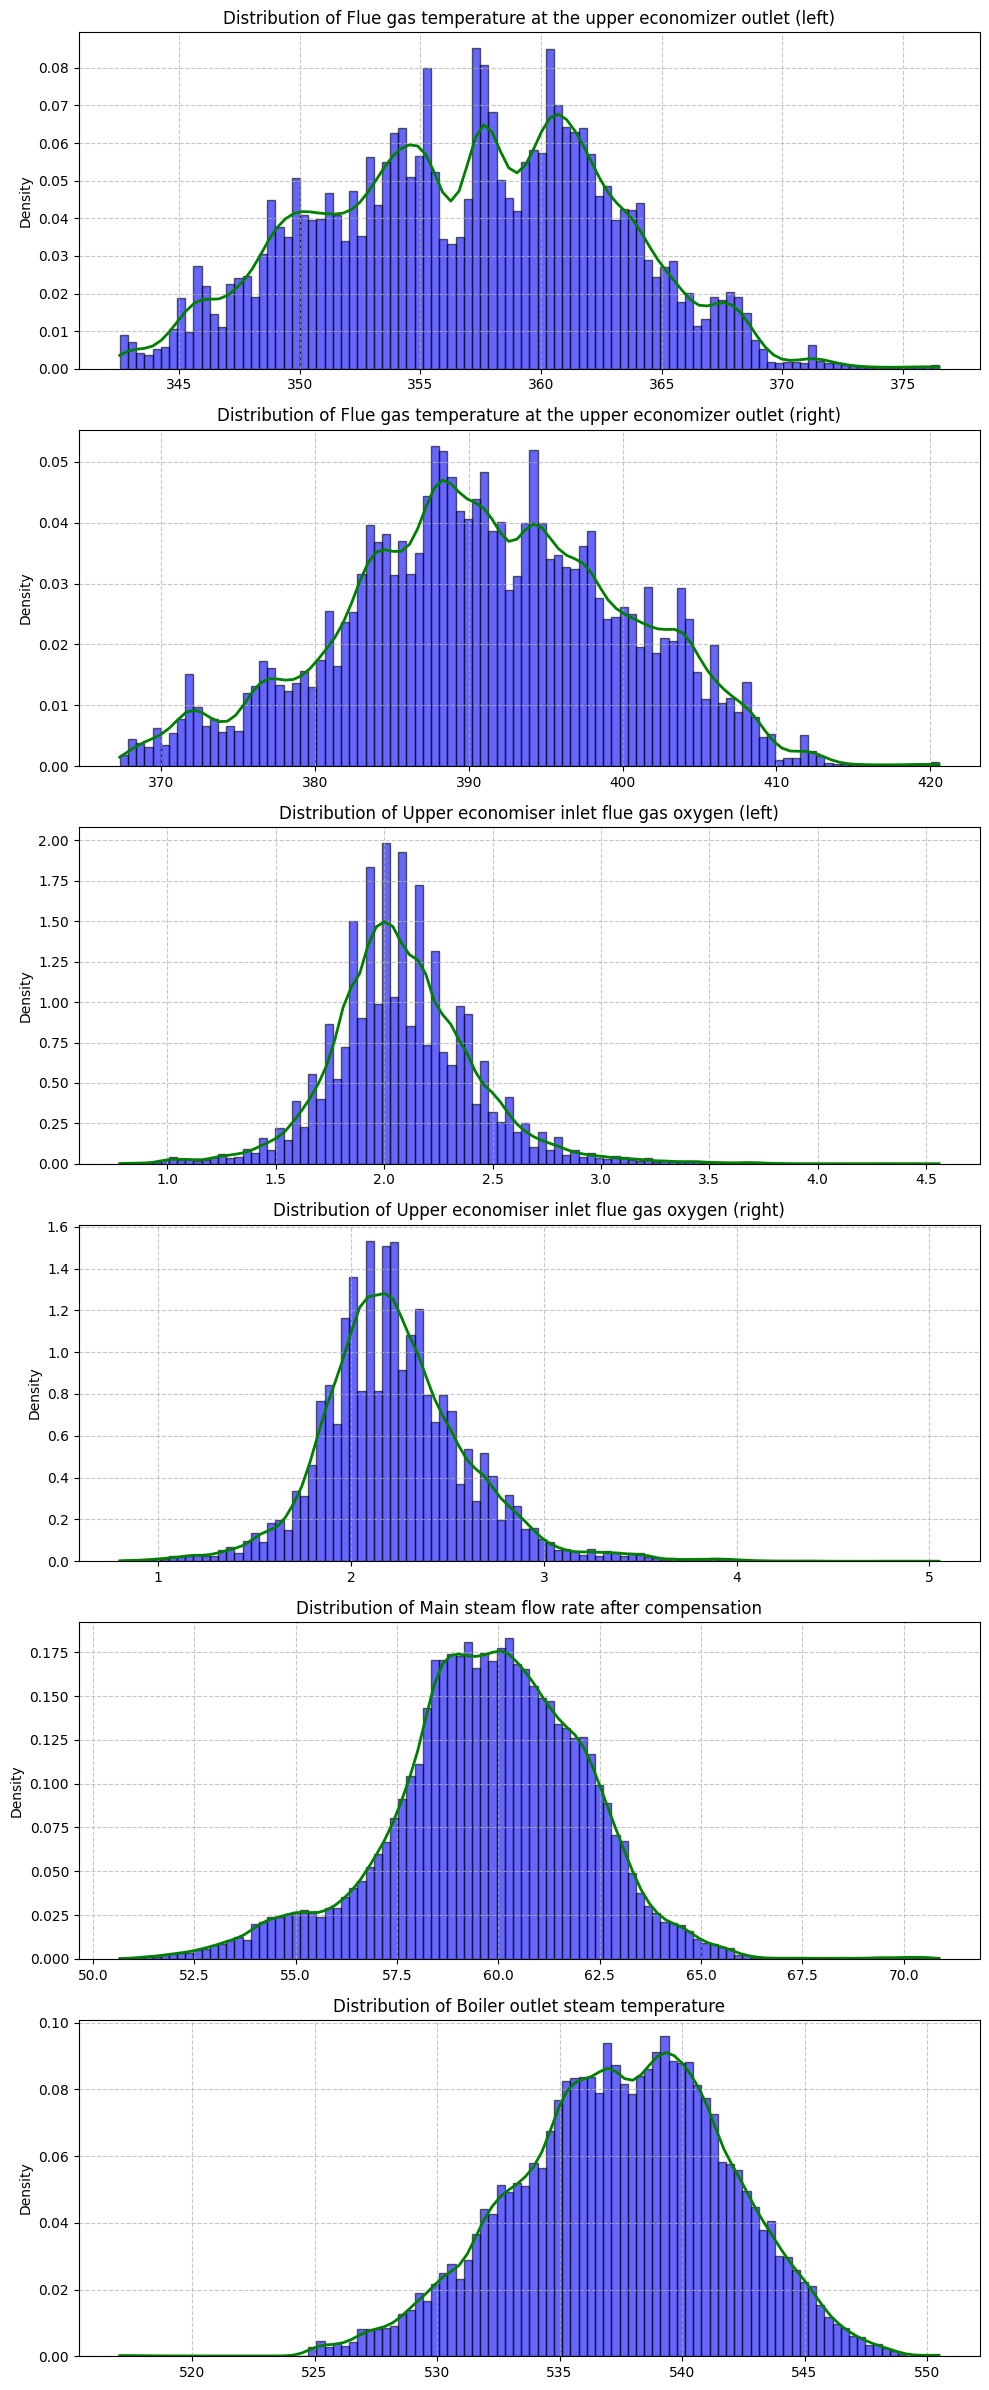

In [23]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import gaussian_kde

def calculate_csv_stats_and_plot(input_path, output_path="stats_output.csv"):
    # Read the CSV file
    df = pd.read_csv(input_path)

    # Define the specific columns to analyze
    selected_columns = [
        'Flue gas temperature at the upper economizer outlet (left)',
        'Flue gas temperature at the upper economizer outlet (right)',
        'Upper economiser inlet flue gas oxygen (left)',
        'Upper economiser inlet flue gas oxygen (right)',
        'Main steam flow rate after compensation',
        'Boiler outlet steam temperature'
    ]

    # Verify that selected columns exist in the DataFrame
    valid_columns = [col for col in selected_columns if col in df.columns]
    if not valid_columns:
        print("Error: None of the specified columns found in the CSV file.")
        return

    # Initialize lists to store statistics
    stats_dict = {
        'Column': [],
        'Mean': [],
        'Std_Dev': [],
        'Variance': [],
        'Skewness': [],
        'Kurtosis': []
    }

    # Calculate statistics for each specified column
    for column in valid_columns:
        # Convert column to numeric, coercing errors to NaN
        df[column] = pd.to_numeric(df[column], errors='coerce')

        if df[column].dtype in ['float64', 'int64'] and df[column].notna().sum() > 0:
            stats_dict['Column'].append(column)
            # Round all calculations to 2 decimal places
            stats_dict['Mean'].append(round(df[column].mean(), 2))
            stats_dict['Std_Dev'].append(round(df[column].std(), 2))
            stats_dict['Variance'].append(round(df[column].var(), 2))
            stats_dict['Skewness'].append(round(stats.skew(df[column], nan_policy='omit'), 2))
            stats_dict['Kurtosis'].append(round(stats.kurtosis(df[column], nan_policy='omit'), 2))

            # Print statistics for the column
            print(f"\nStatistics for column '{column}':")
            print(f"Mean: {stats_dict['Mean'][-1]:.2f}")
            print(f"Standard Deviation: {stats_dict['Std_Dev'][-1]:.2f}")
            print(f"Variance: {stats_dict['Variance'][-1]:.2f}")
            print(f"Skewness: {stats_dict['Skewness'][-1]:.2f}")
            print(f"Kurtosis: {stats_dict['Kurtosis'][-1]:.2f}")
        else:
            print(f"\nWarning: Column '{column}' contains no valid numeric data.")

    # Create DataFrame from statistics
    stats_df = pd.DataFrame(stats_dict)

    # Save to CSV
    if not stats_df.empty:
        stats_df.to_csv(output_path, index=False)
        print(f"\nStatistics saved to {output_path}")
    else:
        print("\nError: No valid statistics to save. Check if columns contain numeric data.")
        return

    # Generate histogram with KDE for each column
    if not valid_columns:
        print("\nError: Cannot generate plots due to no valid columns.")
        return

    print("\nGenerating histograms with KDE for each column...")

    # Create a figure with subplots (one per column)
    n_columns = len(valid_columns)
    fig, axes = plt.subplots(n_columns, 1, figsize=(10, 4 * n_columns), sharex=False)

    # Ensure axes is a list even for a single subplot
    if n_columns == 1:
        axes = [axes]

    # Plot histogram with KDE for each valid column
    for i, column in enumerate(valid_columns):
        # Get non-NaN data
        data = df[column].dropna()

        if len(data) > 0:
            # Create histogram
            axes[i].hist(data, bins=100, density=True, alpha=0.6, color='blue', edgecolor='black')

            # Calculate and plot KDE
            kde = gaussian_kde(data)
            x_range = np.linspace(min(data), max(data), 100)
            kde_values = kde(x_range)
            axes[i].plot(x_range, kde_values, color='green', lw=2)

            axes[i].set_title(f'Distribution of {column}')
            axes[i].set_ylabel('Density')
            axes[i].grid(True, linestyle='--', alpha=0.7)
        else:
            axes[i].text(0.5, 0.5, 'No valid data', ha='center', va='center')
            axes[i].set_title(f'Distribution of {column}')

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()

# Example usage
if __name__ == "__main__":
    # Replace with your CSV file path
    calculate_csv_stats_and_plot('/content/data modified.csv')